# 4. Model Validation

This notebook guides you through selecting and validating climate models (CMIP6 and CORDEX) for use in the attribution study.

---

## How to Use This Notebook

**1. Follow the numbered steps in order.**  
Each section builds upon the previous one, from setup, data loading, and climatology computation, to event analysis and visualization.

**2. Look for <font color="orange"> Orange cells  </font> and code cells marked as <font color="lightgreen">##### (User selection) ##### </font>:** 
| <font color="orange"> Orange cells  </font> | <font color="orange"> Need user intervention </font>|
| ----------- | ----------- |
| <font color="green">**Green cells** </font> | <font color="green">**Run automatically on user input provided in the orange cells and should not be adjusted in most cases** </font>|


**3. Run cells sequentially.**  
Start from the top and execute each cell (`Shift` + `Enter`).  

---

## What This Notebook Does

This notebook helps you:
- Load CMIP6 and CORDEX data (daily mean Tmax, Tmean, Tmin, precipitation)
- Validate models based on:
  - Seasonal cycle shape
  - Climatological spatial pattern
  - Distribution fit parameters
- Decide which models to keep for Step 5 (Attribution)

---


In [1]:
# Imports
from c3s_lib import DataClient, Plot, Process, Utils
import requests
import urllib.parse
import matplotlib.pyplot as plt
import cartopy 
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.io.shapereader as shpreader
import json
import geopandas as gpd
import rasterio
from rasterio import features
from shapely.geometry import shape, Polygon, mapping, MultiPolygon, GeometryCollection
from shapely.vectorized import contains # replace with below
from shapely import contains_xy
import xarray as xr
import numpy as np
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from shapely.ops import unary_union
from datetime import datetime, timedelta
import pandas as pd
import contextily as ctx
import math
import regionmask
import matplotlib.dates as mdates
from matplotlib.patches import Rectangle
import cmocean
import base64
from io import BytesIO
import contextily as ctx
from typing import Union, Literal
import os
import rpy2.robjects as ro
from rpy2.robjects.packages import importr
from rpy2.robjects.conversion import localconverter
from rpy2.robjects import pandas2ri
from rpy2.robjects.vectors import ListVector
from collections import defaultdict
from pathlib import Path
from scipy.stats import chi2
# import R libraries from WWA
ro.r('''if (!requireNamespace("devtools", quietly = TRUE)) {install.packages("devtools", repos="https://cloud.r-project.org", quiet=TRUE)}''')
ro.r('devtools::install_github("WorldWeatherAttribution/rwwa")')
rwwa = importr("rwwa")
%load_ext rpy2.ipython
from dask.distributed import Client


cant import iris, are you on windows?


Error importing in API mode: ImportError('On Windows, cffi mode "ANY" is only "ABI".')
Trying to import in ABI mode.
R callback write-console: Using GitHub PAT from the git credential store.
  
R callback write-console: Skipping install of 'rwwa' from a github remote, the SHA1 (236d9a6b) has not changed since last install.
  Use `force = TRUE` to force installation
  


### <font color="orange"> User specifications </font>

In [2]:
# Api key used for the DataClient, replace with your own API key from the C3S Climate Data Store
################# (User selection) ###################
your_api_key = '3cd17835-a572-4a0c-aaeb-334f01427616'
######################################################

# Do not touch
CURRENT_DIRECTORY = os.getcwd() 

# Directory you wish to store output files in, using ../ specifies the parent directory
################# (User selection) ###################
your_save_directory = os.path.abspath(os.path.join(CURRENT_DIRECTORY, "../data"))   # change ../data to your desired directory
######################################################

# Create directory if it does not exist
os.makedirs(your_save_directory, exist_ok=True) 

## 4a. List of models

CMIP6

CORDEX


In [3]:

domain = "EUR-11"
variable = "tas"

catalog_path = Path(f"{your_save_directory}/projections_cordex_domains_single_levels-ZARR-Access-new.txt")
assert catalog_path.exists(), f"Catalog not found: {catalog_path.resolve()}"

def build_cordex_model_pairs(catalog_file: Path, domain_name: str, experiments = ("hist", "rcp85"), temporal_filter: str = "day"):

    """Return CORDEX model entries that have the requested experiments."""

    domain_key = domain_name.lower().replace("-", "")
    grouped = defaultdict(dict)

    with catalog_file.open("r", encoding="utf-8") as handle:
        for raw_line in handle:

            url = raw_line.strip()

            if not url or url.startswith("#"):
                continue

            descriptor = Path(url).parts[-2]

            try:
                dom_code, experiment_code, temporal_res, remainder = descriptor.split("-", 3)

            except ValueError:
                continue  # skip unexpected formats

            if dom_code.lower() != domain_key:
                continue

            if temporal_filter and temporal_res.lower() != temporal_filter:
                continue

            experiment_code = experiment_code.lower()

            if experiment_code not in experiments:
                continue

            try:
                gcm_rcm, member = remainder.rsplit("-", 1)
                gcm, rcm = gcm_rcm.split("-", 1)

            except ValueError:
                continue

            grouped[(gcm, rcm, member, temporal_res.lower())][experiment_code] = url

    model_list = []

    for (gcm, rcm, member, temporal), entries in grouped.items():
        if all(exp in entries for exp in experiments):
            model_list.append({
                "gcm": gcm,
                "rcm": rcm,
                "member": member,
                "temporal": temporal,
                "hist_url": entries["hist"],
                "rcp85_url": entries["rcp85"],
            })

    # member priority order
    member_order = ["r1i1p1", "r2i1p1", "r3i1p1", "r6i1p1", "r12i1p1", "r0i0p0"]
    priority = {m: i for i, m in enumerate(member_order)}

    # Filter duplicates based on (gcm, rcm)
    filtered_models = {}
    for entry in model_list:
        key = (entry["gcm"], entry["rcm"])
        current_member = entry["member"]

        if key not in filtered_models:
            # first one seen → keep
            filtered_models[key] = entry
        else:
            # compare priority; lower index = higher priority
            existing = filtered_models[key]
            if priority.get(current_member, 999) < priority.get(existing["member"], 999):
                filtered_models[key] = entry

    # replace original list with filtered one
    model_list = list(filtered_models.values())

    return sorted(model_list, key=lambda item: (item["gcm"], item["rcm"], item["member"], item["temporal"]))

cordex_models = build_cordex_model_pairs(catalog_path, domain)
print(len(cordex_models))

10


In [4]:
ARCO_BEARER_TOKEN = os.getenv("ARCO_BEARER_TOKEN", "3683c130-f99a-42ab-9a6e-b4411587136a")
import random

def lazy_merge_and_validate(models, variable_name, bearer_token, max_models=None):
    storage_options = {"headers": {"Authorization": f"Bearer {bearer_token}"}}
    valid_models = []
    dropped_models = []
    for entry in models:
        hist_ds = rcp85_ds = None

        try:
            hist_ds = xr.open_zarr(entry["hist_url"], chunks={}, consolidated=True, storage_options=storage_options)
            #rcp85_ds = xr.open_zarr(entry["rcp85_url"], chunks={}, consolidated=True, storage_options=storage_options)
            hist_var = hist_ds[variable_name].expand_dims(experiment=["historical"])
            #rcp85_var = rcp85_ds[variable_name].expand_dims(experiment=["rcp85"])
            #merged = xr.concat([hist_var, rcp85_var], dim="experiment")
            
            valid_models.append({**entry, "experiment_data": hist_var})
            if max_models is not None and len(valid_models) >= max_models:
                break

        except KeyError:
            dropped_models.append(entry)

        finally:
            for ds in (hist_ds, rcp85_ds):
                close = getattr(ds, "close", None)
                if callable(close):
                    close()
    if max_models is not None and len(valid_models) > max_models:
        valid_models = random.sample(valid_models, max_models)
    return valid_models, dropped_models


cordex_models, cordex_models_dropped = lazy_merge_and_validate(cordex_models, variable, ARCO_BEARER_TOKEN, max_models=20)

print(f"Validated {len(cordex_models)} CORDEX models with '{variable}' available; dropped {len(cordex_models_dropped)}.")


Validated 10 CORDEX models with 'tas' available; dropped 0.


---

## 4b. Model Validation Procedure

In [12]:
parameter = 'tas'

# Setting up the parameter specific variables
if parameter in ["Tmax", "Tmean", "Tmin", "tas"]:
    variable = "Temperature"
    value_col = "t2m"
    y_label = "c"
    unit = "°C"
    calculation = "absolute"  # absolute or relative
    method = "Mean" 
elif parameter == "Precipitation":
    variable = "Precipitation"
    value_col = "tp"
    y_label = "mm"
    unit = "mm"
    calculation = "relative"  # absolute or relative
    method = "Total"

event_end = datetime(2025, 7, 10) 

# load study region 
# study_region = gpd.read_file(r"D:\Git\c3s-451\data\sf_studyregion.shp")
study_region = gpd.read_file(Path(f"{your_save_directory}\sf_studyregion.shp"))


DataSourceError: Unable to open c:\Users\jasper\Desktop\c3s-451\data\sf_studyregion.shx or c:\Users\jasper\Desktop\c3s-451\data\sf_studyregion.SHX. Set SHAPE_RESTORE_SHX config option to YES to restore or create it.

In [ ]:
################# (User selection) ###################
# Area of interest bounding box:
# (deg Southern boundary, Western boundary, Northern boundary, Eastern boundary)
bbox = (44, -11, 55, 10)
bbox = convert_bbox(*bbox)
xn,xx,yn,yx = [study_region.geometry.bounds.minx[0] - 5, study_region.geometry.bounds.maxx[0] + 5, study_region.geometry.bounds.miny[0] - 5, study_region.geometry.bounds.maxy[0] + 5]######################################################


In [ ]:
#load observed seasonal cycle data
obs_seasonal_cycle = xr.open_dataset(r"D:\Git\c3s-451\data\seasonal_cycle_1991-2020.nc")
obs_climatology = xr.open_dataset(r"D:\Git\c3s-451\data\climatology_1991-20202.nc")

### 4.1 General Properties

a.	Model resolution vs event spatial scale. Is the resolution of the model sufficient to represent the event and for comparison with observations? 
i.	For precipitation, in case of convective precipitation events: 
1.a.i.1.	If the event is large scale but convection is clearly present, omit CMIP6 and use only CORDEX
1.a.i.2.	 If the event is large scale but convection plays a major role (e.g. organised convection in thunderstorms), no attribution possible without convection permitting models and we can’t use CMIP6 or CORDEX.
ii.	For precipitation, if the event happens close to an orographic barrier, omit CMIP6.
iii.	Else, use both CORDEX and CMIP6


b. Seasonal Cycle

b.	Does the model seasonal cycle resemble the observed seasonal cycle? Calculate and plot model seasonal cycles (years same as in observations) and overlay with observed seasonal cycle. Compare figures of seasonal cycle calculated by e.g. simple averages, especially for precipitation, expert judgement. 
i.	E.g. Do the peaks in the model seasonal cycle correspond to the peaks in observations (in timing)? 
ii.	Note seasonal cycle as “good” (peaks resemble the observed peaks), “reasonable” (peaks resemble most important features but there are some differences) or “bad” (peaks do not resemble observed peaks). Expert judgement.
iii.	Write findings and decisions in table.


In [ ]:

from aiohttp.client_exceptions import (
    ClientResponseError,
    ClientConnectionError,
    ServerTimeoutError,
    ConnectionTimeoutError,
)
import asyncio

seasonal_cycles = {}
processed_models = []
for entry in cordex_models:
    model_label = f"{entry['gcm']} / {entry['rcm']}"
    print(f"Fetching and processing data for model:{model_label}")
    try:
        hist = xr.open_zarr(entry["hist_url"], consolidated=True, storage_options = {"headers": {"Authorization": f"Bearer 3683c130-f99a-42ab-9a6e-b4411587136a"}})
        rpc85 = xr.open_zarr(entry["rcp85_url"], consolidated=True, storage_options = {"headers": {"Authorization": f"Bearer 3683c130-f99a-42ab-9a6e-b4411587136a"}})
        hist = hist[parameter]
        rpc85 = rpc85[parameter]
        merged = xr.concat([hist, rpc85], dim="time")
        da = merged
        da = wrap_lon(da)
        da = da - 273.15

        # different RCMs use different coordinate systems, so identify the x & y dims
        if "rlon" in da.dims:
            xdim,ydim = ["rlon", "rlat"]
        elif "x" in da.dims:
            xdim,ydim = ["x", "y"]
        else:
            xdim,ydim = ["longitude", "latitude"]

        rm = regionmask.mask_geopandas(study_region, da.longitude, da.latitude)

        # compute time series of mean over region
        ts = da.where(rm == 0, drop = True).mean([xdim, ydim])
        ts = ts.sortby("time")

        sc = ts.sel(time = slice("1990", "2020")).groupby("time.dayofyear").mean()

        name = f"{entry['gcm']}\n{entry['rcm']}"
        seasonal_cycles[name] = sc.compute()
        processed_models.append(entry)
        print("Processed succesfully")
    except (
        ClientResponseError,
        ClientConnectionError,
        ServerTimeoutError,
        ConnectionTimeoutError,
        asyncio.TimeoutError,
    ) as exc:
        cordex_models_dropped.append(entry)
        status = getattr(exc, "status", "n/a")
        print(f"Fetching failed ({status}), skipping model")
        continue
    except Exception as exc:
        cordex_models_dropped.append(entry)
        print(f"Fetching failed ({exc}), skipping model")
        continue
print(f"Seasonal cycles computed for {len(processed_models)} models; dropped {len(cordex_models_dropped)}.")
n_models = len(seasonal_cycles)
cordex_models = processed_models


Fetching and processing data for model:cccma_canesm2 / clmcom_clm_cclm4_8_17
Processed succesfully
Fetching and processing data for model:cccma_canesm2 / gerics_remo2015
Processed succesfully
Seasonal cycles computed for 2 models; dropped 0.


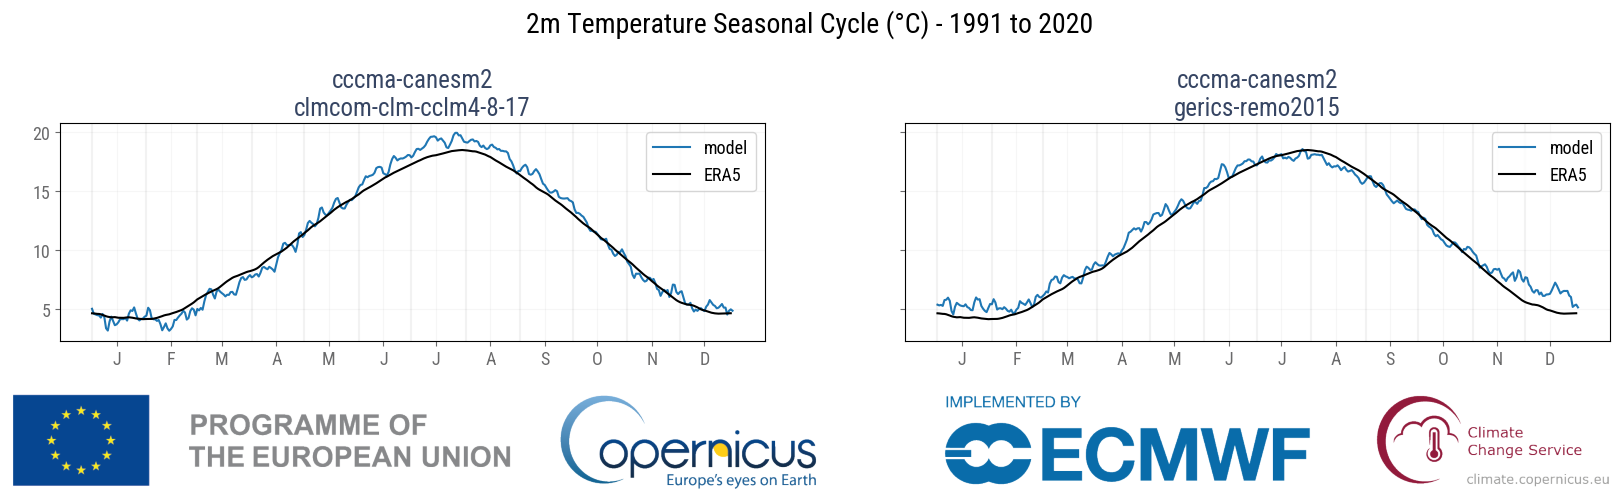

In [ ]:
title = "2m Temperature Seasonal Cycle (°C) - 1991 to 2020"
fig, ax, img_ax = plot_seasonal_cycles(seasonal_cycles, obs_seasonal_cycle, value_col=value_col, legend_title=title)

c.	Does the model climatology - the spatial pattern of the variable (e.g. mean temperature over 1991-2020) - resemble the observed spatial pattern? Calculate and plot model spatial patterns and observed spatial pattern and compare figures, expert judgement. Use the same years as in observations. 
i.	Note as “good” (main peaks and troughs overlapping in location with observed peaks and troughs, and relative amplitudes of features are ok), “reasonable” (most of the main features are captured) or “bad” (few of the main features are captured). 
ii.	Write findings and decisions in table.


In [ ]:
from aiohttp.client_exceptions import (
    ClientResponseError,
    ClientConnectionError,
    ServerTimeoutError,
    ConnectionTimeoutError,
)
import asyncio

spatial_maps = {}
processed_models = []
for entry in cordex_models:
    model_label = f"{entry['gcm']} / {entry['rcm']}"
    print(f"Fetching and processing data for model:{model_label}")
    try:
        hist = xr.open_zarr(entry["hist_url"], consolidated=True, storage_options = {"headers": {"Authorization": f"Bearer 3683c130-f99a-42ab-9a6e-b4411587136a"}})
        rpc85 = xr.open_zarr(entry["rcp85_url"], consolidated=True, storage_options = {"headers": {"Authorization": f"Bearer 3683c130-f99a-42ab-9a6e-b4411587136a"}})
        hist = hist[parameter]
        rpc85 = rpc85[parameter]
        merged = xr.concat([hist, rpc85], dim="time")

        da = merged
        da = wrap_lon(da)
        da = da - 273.15

        # different RCMs use different coordinate systems, so identify the x & y dims
        if "rlon" in da.dims:
            xdim,ydim = ["rlon", "rlat"]
        elif "x" in da.dims:
            xdim,ydim = ["x", "y"]
        else:
            xdim,ydim = ["longitude", "latitude"]

        # Subset region
        da_box = da.sel(
            longitude=slice(bbox[0], bbox[2]),
            latitude=slice(bbox[1], bbox[3])
        )

        # Model climatology
        da_box = da_box.sortby("time")
        da_clim = da_box.sel(time=slice("1990", "2020")).mean("time")

        name = f"{entry['gcm']}\n{entry['rcm']}"
        spatial_maps[name] = da_clim.compute()
        processed_models.append(entry)
        print("Processed succesfully")

    except (
        ClientResponseError,
        ClientConnectionError,
        ServerTimeoutError,
        ConnectionTimeoutError,
        asyncio.TimeoutError,
    ) as exc:
        cordex_models_dropped.append(entry)
        status = getattr(exc, "status", "n/a")
        print(f"Fetching failed ({status}), skipping model")
        continue
    except Exception as exc:
        cordex_models_dropped.append(entry)
        print(f"Fetching failed ({exc}), skipping model")
        continue
print(f"Spatial maps computed for {len(processed_models)} models; dropped {len(cordex_models_dropped)}.")
n_models = len(spatial_maps)
cordex_models = processed_models

Fetching and processing data for model:cccma_canesm2 / clmcom_clm_cclm4_8_17
Processed succesfully
Fetching and processing data for model:cccma_canesm2 / gerics_remo2015
Processed succesfully
Spatial maps computed for 2 models; dropped 0.


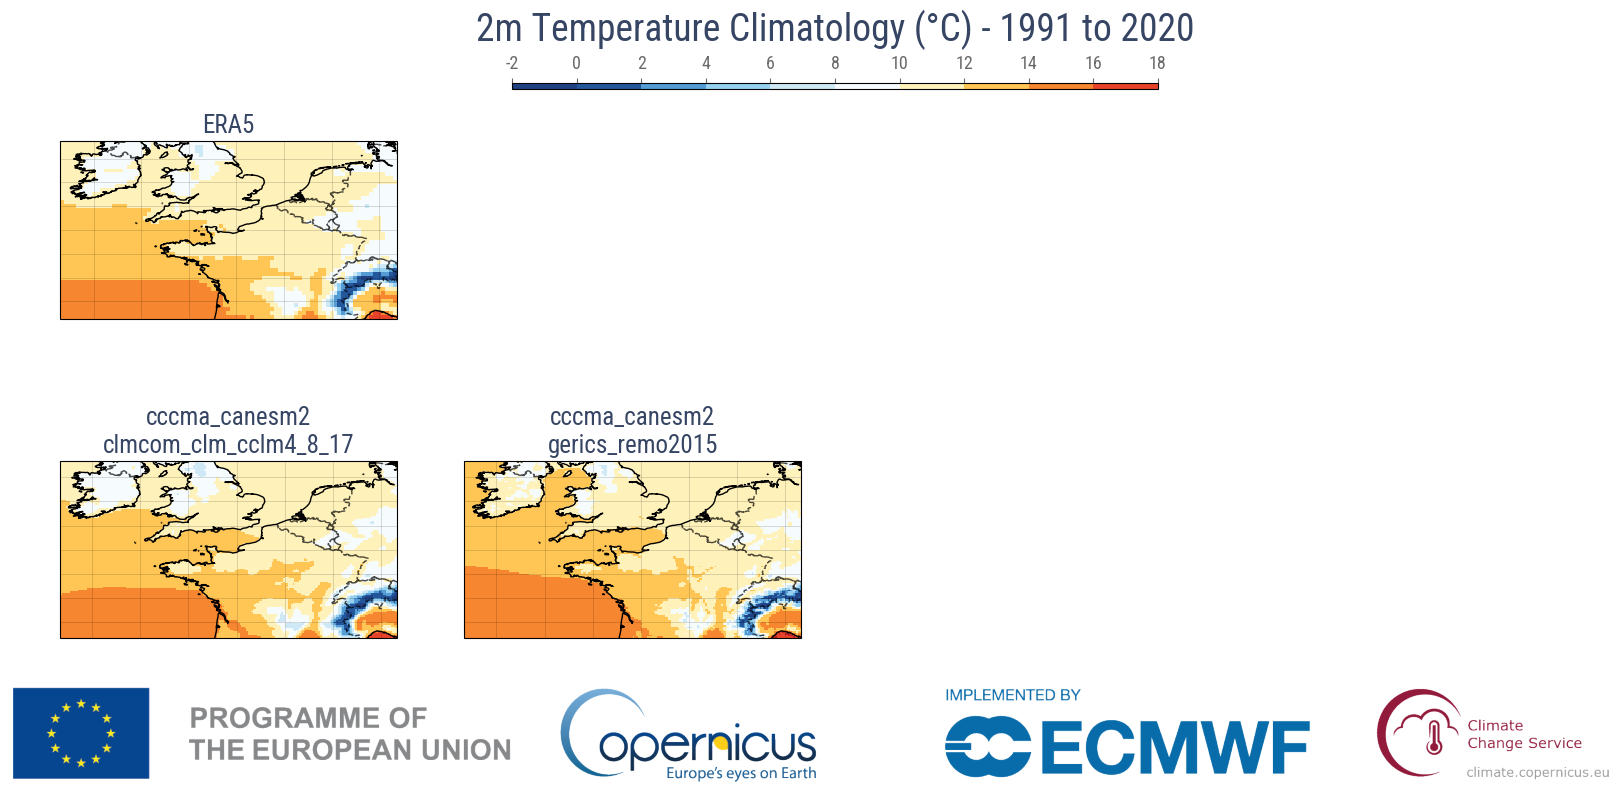

In [ ]:

title = "2m Temperature Climatology (°C) - 1991 to 2020"
fig, axs, img_ax = plot_spatial_maps(obs_climatology[value_col], spatial_maps, value_col=value_col, legend_title=title)

d.	If necessary, exclude model runs that require a large bias correction resulting in the event magnitude at the event return period being very different, e.g. an order of magnitude different, to the observed. This is problematic, for example, for event temperatures around 0 ℃ (because of the model physics linked to change of state), or very low (>2x too low) precipitation values etc.  see Step 5.1e.
i.	Write findings and decisions in table (comments).


### 4.2 Decide on model ensembles

4.2	Decide on the model ensembles (CMIP6, which regional CORDEX domain), are considered further for analysis, write down in the scientific report Section 2.2.

### 4.3 Model Time Series

4.3	Calculate the model time series over the same event definition as for observations 
a.	Calculate area average to obtain the annual time series
b.	Calculate the temporal average to obtain the annual time series
c.	Save all model time series


In [ ]:
time_series = {}
processed_models = []
for entry in cordex_models:
    model_label = f"{entry['gcm']} / {entry['rcm']}"
    print(f"Fetching and processing data for model:{model_label}")
    try:
        hist = xr.open_zarr(entry["hist_url"], consolidated=True, storage_options = {"headers": {"Authorization": f"Bearer 3683c130-f99a-42ab-9a6e-b4411587136a"}})
        rpc85 = xr.open_zarr(entry["rcp85_url"], consolidated=True, storage_options = {"headers": {"Authorization": f"Bearer 3683c130-f99a-42ab-9a6e-b4411587136a"}})
        hist = hist[parameter]
        rpc85 = rpc85[parameter]
        merged = xr.concat([hist, rpc85], dim="time")

        da = merged
        da = wrap_lon(da)
        da = da - 273.15

        da = da.sortby("time")
        da = da.sel(time=slice("1950", "2025"))

        # Subset over the study region
        if "rlon" in da.dims:
            xdim,ydim = ["rlon", "rlat"]
        elif "x" in da.dims:
            xdim,ydim = ["x", "y"]
        else:
            xdim,ydim = ["longitude", "latitude"]

        rm = regionmask.mask_geopandas(study_region, da.longitude, da.latitude)
        # compute time series of mean over region
        da = da.where(rm == 0, drop = True)

        # Give each cell a weight based on its size (latitude related)
        da = weighted_values(da, value_col=None, lat_col='latitude')

        # Calculate spatial mean
        da = da.mean(dim=[xdim, ydim])
        da = da

        name = f"{entry['gcm']}\n{entry['rcm']}"
        time_series[name] = da.compute()
        processed_models.append(entry)
        print("Processed succesfully")

    except (
        ClientResponseError,
        ClientConnectionError,
        ServerTimeoutError,
        ConnectionTimeoutError,
        asyncio.TimeoutError,
    ) as exc:
        cordex_models_dropped.append(entry)
        status = getattr(exc, "status", "n/a")
        print(f"Fetching failed ({status}), skipping model")
        continue
    except Exception as exc:
        cordex_models_dropped.append(entry)
        print(f"Fetching failed ({exc}), skipping model")
        continue


print(f"Time series computed for {len(processed_models)} models; dropped {len(cordex_models_dropped)}.")
n_models = len(time_series)
cordex_models = processed_models

Fetching and processing data for model:cccma_canesm2 / clmcom_clm_cclm4_8_17
Processed succesfully
Fetching and processing data for model:cccma_canesm2 / gerics_remo2015
Processed succesfully
Time series computed for 2 models; dropped 0.


In [ ]:
################### User Selection  ##################
# Choose mean, max, min
yearly_value = 'max'

# Padding >= 1 : rolling window, n-days (centered)
padding = 3

# Choose month range, e.g. (1, 12) or (12, 1), ..
month_range = (1, 12)

# Standard method for temperature: mean and for precipitation: sum, if not specified
# If you want to change it, specify here
method = 'mean'
#######################################################

In [ ]:

da_yearly_series = calculate_yearly_statistics(
    time_series=time_series, 
    yearly_value=yearly_value, 
    padding=padding
)

### 4.4 Model GMST (4-year smoothed)

In [ ]:
event_year = 2025
year_range = (1951, event_year)

# location of the gmst data
gmst_url = "https://data.giss.nasa.gov/gistemp/tabledata_v4/GLB.Ts+dSST.csv"

method = "mean"

# import gmst data as seen in
# https://github.com/maris-development/c3s-451/blob/development/input-notebooks/notebooks/gmst.ipynb

datetime_col = "valid_time"
value = "gmst"

# read in the data
gmst = (
    pd.read_csv(
        gmst_url,
        na_values=["****", "***"],
        index_col=0,
        skiprows=1,
        comment="#",
    )
)

# unpivot the df
gmst_monthly = (
    pd.concat([
        pd.DataFrame({
            datetime_col: [datetime(y, i + 1, 1) for y in gmst.index],
            value: gmst.iloc[:, i].values
        })
        for i in range(12)
    ])
    .sort_values(datetime_col)
    .dropna(subset=[value])
    .reset_index(drop=True)
)
gmst_monthly

# calculate the rolling mean
gmst_monthly_rolled = calculate_rolling_window(gdf=gmst_monthly, value_col=value, datetime_col=datetime_col,
                                               window=48, min_periods=24, centering=True, method=method)
# select only the specified years
gmst_monthly_rolled = subset_gdf(gdf=gmst_monthly_rolled, datetime_col=datetime_col, year_range=year_range)
gmst_monthly_rolled

gmst_yearly, rolled_gdf = calculate_yearly_value(gdf=gmst_monthly_rolled, value_col=value, datetime_col=datetime_col, yearly_value=method)
gmst_yearly

# calculate anomaly relative to event year
ref_val = gmst_yearly.loc[gmst_yearly["year"] == event_year, value].values[0]
gmst_yearly[value] = gmst_yearly[value] - ref_val

In [ ]:
# gmst to xarray
gmst_yearly = xr.DataArray(
    data=gmst_yearly['gmst'].values, coords={'year': gmst_yearly['year'].values})
gmst_yearly

<xarray.DataArray (year: 75)> Size: 600B
array([-1.30980901, -1.28321179, -1.26892359, -1.31791665, -1.35142359,
       -1.31803818, -1.2783854 , -1.24081596, -1.20689234, -1.22109373,
       -1.22652776, -1.22854165, -1.28380207, -1.31282984, -1.32810762,
       -1.33102429, -1.29717012, -1.2577604 , -1.25743054, -1.26052082,
       -1.2165104 , -1.23217012, -1.22409721, -1.23076387, -1.25130207,
       -1.22623262, -1.20616318, -1.12194443, -1.06225693, -1.04107637,
       -0.99501734, -0.99902776, -1.04171873, -1.05031248, -1.0605729 ,
       -1.02359373, -0.97861109, -0.92579859, -0.87350693, -0.88249998,
       -0.90548609, -0.9430729 , -0.94623262, -0.94050346, -0.90020832,
       -0.81218748, -0.79329859, -0.78737846, -0.77305554, -0.76406248,
       -0.73835068, -0.69029512, -0.64980901, -0.64217012, -0.61664929,
       -0.62371526, -0.62190971, -0.60237846, -0.61565971, -0.60112846,
       -0.58491318, -0.5868229 , -0.54637151, -0.44777776, -0.37623262,
       -0.34048609, -0.31371526, -0.30993054, -0.32592012, -0.31718748,
       -0.30309026, -0.24086804, -0.15046873, -0.08003526,  0.        ])
Coordinates:
  * year     (year) int32 300B 1951 1952 1953 1954 1955 ... 2022 2023 2024 2025

### 4.5 Statistical Properties

4.5	Statistical properties – this Step only contains the guidelines on how to decide on the model validation for the statistical fit parameters, see Sec. 5. Probabilistic attribution for the actual analysis to perform:
a.	Use the same statistical model (e.g. Gauss/GEV/..., shift/scale) as in observations, see also 3.4 for details and checks 
b.	Plot and visually check the scale or dispersion parameter of the annual maximum time series. Add a sentence on caution to the scientific report Section 4. (software: this is not coded yet), see Step 3.2.b;  
c.	Use bias-correction via threshold: evaluate model for same return period as in observations. This determines the model threshold. (See also Step 4.1.d for validation decision.) 
d.	Compare statistical fit parameters over a period as similar as possible to the observed data: for ‘now’, or spanning the same historical period (e.g. 1950-now). Check findings in the automated output table and combine with general properties into one conclusion. If necessary, changes can be made to specific output and conclusions.
i.	if the best estimate(s) of the fit parameters (σ or σ/μ, ξ) are within the observed confidence interval(s), the model is considered to be good enough (good). 
ii.	If the confidence interval(s) of the fit parameters (σ or σ/μ, ξ) partially overlap (at least 5% overlap), the model is considered to be good enough (reasonable, use with care and make sure the uncertainty is expressed in the final attribution statement). 
iii.	If the confidence interval(s) of the fit parameters (σ or σ/μ, ξ) do not overlap), the model is considered not good enough (bad) and the models should be excluded from the synthesis.


In [ ]:
################# (User selection) ###################
annual_timeseries_load = 'ts_ann_studyregion.nc'
######################################################
ts_ann_studyregion = xr.open_dataset(os.path.join(your_save_directory, annual_timeseries_load))

ts_ann_studyregion = ts_ann_studyregion['t2m'].to_dataframe().reset_index()

In [ ]:
#drop from a range of years if needed
ts_ann_studyregion = ts_ann_studyregion[(ts_ann_studyregion['year'] >= 1954) & (ts_ann_studyregion['year'] <= 2023)]
ts_ann_studyregion

,year,t2m
2,1954,19.478077
3,1955,22.250318
4,1957,23.246081
5,1958,19.426193
6,1959,22.115863
...,...,...
65,2019,26.454832
66,2020,24.544772
67,2021,21.467699
68,2022,25.290958


In [ ]:
#convert da_yearly_series to dataframe
model_dfs = {}
for name, da in da_yearly_series.items():
    # to_dataframe requires a column name for unnamed DataArrays
    df = da.to_dataframe(name="value").reset_index()

    # add a 'year' column if we have a 'time' index (useful later)
    if "time" in df.columns and "year" not in df.columns:
        df["year"] = pd.DatetimeIndex(df["time"]).year

    model_dfs[name] = df
    

In [ ]:
def calculate_rolling_window_test(
    gdf: Union[pd.DataFrame, gpd.GeoDataFrame],
    value_col: str,
    window: int,
    centering: bool = False,
    datetime_col: str = "valid_time",
    method: Literal["sum", "mean", "std", "quantile", "dispersion"] = "mean",
    quantile: float = 0.9,
    group_by: list[str] = None,
    min_periods: int|None = 1,
    remove_leap_days: bool = False,
    ci: bool = False,
    ci_level: float = 0.95,
):
    """
    Compute rolling statistics (sum, mean, std, quantile) over a fixed-size window.
    Assumes datetime_col is already at the desired temporal resolution (days, months, or years).

    Returns
    -------
    DataFrame or GeoDataFrame
        Same as input, with rolled values in `value_col`.
    """

    if window <= 1:
        return gdf

    gdf = gdf.copy()

    if remove_leap_days:
        # Ensure datetime_col is datetime (should already be if user promised so)
        gdf[datetime_col] = pd.to_datetime(gdf[datetime_col])

        # Drop Feb 29 for yearly data consistency (optional)
        gdf = gdf[~((gdf[datetime_col].dt.month == 2) & (gdf[datetime_col].dt.day == 29))]

    if group_by is None:
        group_by = []

    def apply_roll(group):
        group = group.sort_values(datetime_col)
        roller = group[value_col].rolling(window=window, min_periods=min_periods, center=centering)

        match method:
            case "sum":
                rolled = roller.sum()
            case "mean":
                rolled = roller.mean()
            case "std":
                rolled = roller.std()
            case "quantile":
                rolled = roller.quantile(quantile)
            case "dispersion":
                rolled = roller.std() / roller.mean()
            case _:
                raise ValueError(f"Unsupported method: {method}")

        group[value_col] = rolled
        
        if ci and method in ("std", "dispersion"):
            n = roller.count().reset_index(drop=True)
            alpha = 1 - ci_level
            var = roller.var().reset_index(drop=True)

            chi2_lower = chi2.ppf(1 - alpha / 2, n - 1)
            chi2_upper = chi2.ppf(alpha / 2, n - 1)
            std_lower = np.sqrt((n - 1) * var / chi2_lower)
            std_upper = np.sqrt((n - 1) * var / chi2_upper)

            if method == "std":
                group[f"{value_col}_ci_lower"] = std_lower
                group[f"{value_col}_ci_upper"] = std_upper

            elif method == "dispersion":
                mean_vals = roller.mean().reset_index(drop=True)
                mean_vals = mean_vals.replace(0, np.nan)
                group[f"{value_col}_ci_lower"] = std_lower / mean_vals
                group[f"{value_col}_ci_upper"] = std_upper / mean_vals

        return group

    if group_by:
        result = gdf.groupby(group_by, group_keys=False).apply(apply_roll)
    else:
        result = apply_roll(gdf)

    # Preserve GeoDataFrame type if input was one
    if isinstance(gdf, gpd.GeoDataFrame):
        return gpd.GeoDataFrame(result, geometry="geometry", crs=gdf.crs)
    return result

In [ ]:

# Setting up the parameter specific variables
if parameter in ["Tmax", "Tmean", "Tmin", "tas"]:
    method = "std" 
elif parameter == "Precipitation":
    method = "dispersion"

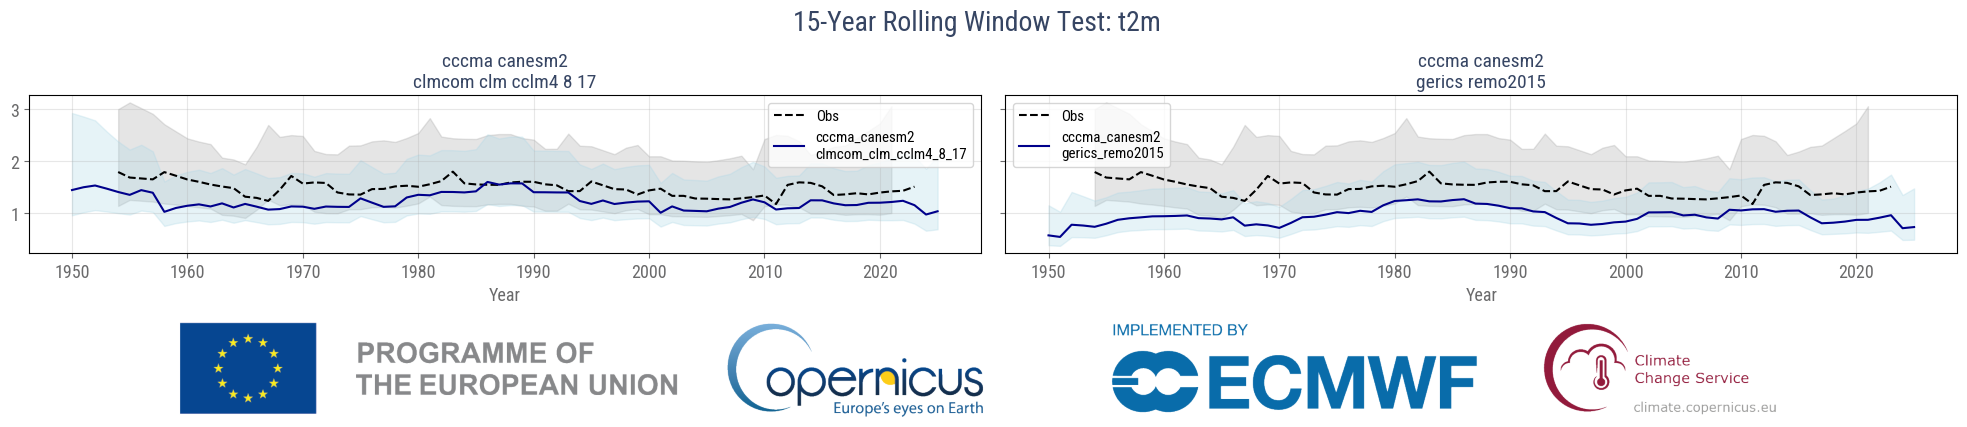

In [ ]:
obs_ann_15ym = calculate_rolling_window_test(gdf=ts_ann_studyregion, value_col=value_col, datetime_col="year",
                                  window=15, method=method, min_periods=1, centering=True, ci=True)

model_dfs_15ym = {}
for name, df in model_dfs.items():
    model_dfs_15ym[name] = calculate_rolling_window_test(gdf=df, value_col='value', datetime_col="year",
                                  window=15, method=method, min_periods=1, centering=True, ci=True)
    

fig, axs, img_ax = plot_rolling_window_comparison(
     model_dfs=model_dfs_15ym, 
     obs_df=obs_ann_15ym, 
     value_col=value_col,
     legend_title=f"15-Year Rolling Window Test: {value_col}"
 )


### 4.6 Decide on which Models to Include

4.6	Decide on which models to include in the model synthesis. Note that if we have enough “good” models we can discuss whether we want to do the synthesis without including the "reasonable" models. If we still use the "reasonable" ones this should be noted as a caution in the associated text.
a.	If, per framing/model setup we have five or more models (from a different model ensemble) that are “good” according to the validation we do not use the “reasonable” models for that framing/model setup but only the “good” models. If we have less than five “good” models, first add only models with one “reasonable”, if still less than five models add models with two “reasonable” labels, etc.
b.	If we have two models stemming from the same model, e.g., a high and a lower resolution model, check (by eye) if the results in the attribution step are the same. If so, only use one of the models, otherwise keep both.
c.	In the scientific report the conclusion will appear in the table with values as ‘yes’ (good), ‘yes (just)’ (reasonable) or ‘no’ (bad).
d.	All decisions that deviate from the above points need to be documented including the reason of the decision.


In [ ]:
# Convert yearly dataframes to R objects

df_yearly_r = {}

for key, df in model_dfs.items():
    with localconverter(ro.default_converter + pandas2ri.converter):
        df_yearly_r[key] = ro.conversion.py2rpy(df)

df_yearly_r = ListVector(df_yearly_r)
ro.globalenv["df_yearly"] = df_yearly_r

# Convert GMST to dataframe
gmst_yearly = pd.DataFrame({'year': gmst_yearly['year'].values, 'gmst': gmst_yearly.values})


In [ ]:
%%R -i gmst_yearly -i ts_ann_studyregion 

library(rwwa)
library(extRemes)

merge_model_gmst <- function(model_df, gmst_df) {
    
    # model_df has: time (POSIXct), value (tasmax)
    # gmst_df has: year, gmst
    # merge on year
    out <- merge(
        model_df[, c("year", "value")],
        gmst_df,
        by = "year",
        all = FALSE
    )
    
    return(out)
}


In [ ]:
%%R -i your_save_directory
# Parameters
rp      <- 20      # return period
y_now   <- 2025
y_start <- 1970
y_fut   <- 2070

# Main loop
model_results <- list()

for (model_name in names(df_yearly)) {
    
    # Clean Name
    clean_name <- gsub("\n", "-", model_name)
    #clean_name <- gsub("[^[:alnum:]-]", "-", clean_name)
    
    cat("Processing:", clean_name, "\n")
 
    # Merge Data
    df <- merge_model_gmst(df_yearly[[model_name]], gmst_yearly)

    library(knitr)
    cat(paste("\n### INPUT DATA merge:", clean_name, "\n"))
    model_preview <- tail(df)
    print(kable(model_preview, format = "pipe"))
    
    if (nrow(df) == 0) {
        warning("No overlap in years for model", clean_name)
        next
    }
    
    # Fit Model
    mdl <- fit_ns(
        dist = "gev",
        type = "shift",
        data = df,
        varnm = "value",
        covnm = "gmst",
        lower = F
    )
    
    # Define Covariates
    cov_now  <- df[df$year == y_now, "gmst", drop = F]

    if (length(cov_now) == 0) cov_now <- tail(df$gmst, 1)
    
    cov_hist <- cov_now - 1.3
    cov_fut  <- cov_now + 1.3
    
    # Get Results

    res <- cmodel_results(
        mdl,
        rp = rp,
        cov_f = cov_now,
        cov_hist = cov_hist,
        cov_fut = cov_fut,
        y_now = y_now,
        y_start = y_start,
        y_fut = y_fut
    )
        
    res_df <- as.data.frame(t(unlist(res)))
    
    # Store in list
    model_results[[clean_name]] <- res_df
    
    # Plotting
    fname <- file.path(your_save_directory, paste0("returnlevels_", clean_name, ".png"))
    val_to_plot <- unlist(res)[,"rp_value"] 
    cat("   -> Extracted RP value for plotting (ev):", val_to_plot, "\n")

    if (!file.exists(fname)) {
        tryCatch({

            png(fname, width = 480, height = 360)
            par(cex.main = 1.4)
            
            # Try to get rp_value from the list/vector safely
            val_to_plot <- unlist(res)[,"rp_value"] 

            cat("   -> Extracted RP value for plotting (ev):", val_to_plot, "\n")
                    
            plot_returnlevels(
                mdl,
                cov_f = cov_now,
                cov_cf = cov_hist,
                ev = val_to_plot, 
                nsamp = 100,
                main = clean_name
            )
            dev.off()
        }, error = function(e) {
            cat("  -> Plotting failed for:", clean_name, ":", e$message, "\n")
            if (dev.cur() > 1) dev.off() # Ensure device closes on error
        })
    }
}

# Combine and Save (Fixes "Unimplemented type list")
cat("\nCombining results...\n")

# Use do.call(rbind) which is safer for data frames than sapply
res_models <- do.call(rbind, model_results)

# Filter for numeric columns only ---
valid_cols <- sapply(res_models, function(x) is.numeric(x) || is.character(x))
res_models_clean <- res_models[, valid_cols, drop = FALSE]

# Save
csv_path <- file.path(your_save_directory, "res-models_cordex.csv")
write.csv(res_models_clean, csv_path)

cat("Success! Saved res-models_cordex.csv\n")


Processing: cccma_canesm2-clmcom_clm_cclm4_8_17 

### INPUT DATA merge: cccma_canesm2-clmcom_clm_cclm4_8_17 


|   | year|    value|       gmst|
|:--|----:|--------:|----------:|
|70 | 2020| 15.53670| -0.3171875|
|71 | 2021| 17.35790| -0.3030903|
|72 | 2022| 15.69263| -0.2408680|
|73 | 2023| 14.89415| -0.1504687|
|74 | 2024| 16.22340| -0.0800353|
|75 | 2025| 14.42198|  0.0000000|
   -> Extracted RP value for plotting (ev): 17.77547 
   -> Extracted RP value for plotting (ev): 17.77547 
Processing: cccma_canesm2-gerics_remo2015 

### INPUT DATA merge: cccma_canesm2-gerics_remo2015 


|   | year|    value|       gmst|
|:--|----:|--------:|----------:|
|70 | 2020| 14.49487| -0.3171875|
|71 | 2021| 14.98481| -0.3030903|
|72 | 2022| 13.50781| -0.2408680|
|73 | 2023| 13.51730| -0.1504687|
|74 | 2024| 14.50422| -0.0800353|
|75 | 2025| 13.35134|  0.0000000|
   -> Extracted RP value for plotting (ev): 15.9283 
   -> Extracted RP value for plotting (ev): 15.9283 

Combining results...
Success! S

In [ ]:
%%R
valid_cols

### 4.7 State other considerations for including or excluding models

### 4.8	Fill column “Include Y/N” for each model with the decision to include “Y” or exclude “N” the model.

---